In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import plotly.express as px

In [4]:
nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

perf = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

bench = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

funds = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

In [5]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

bench["date"] = pd.to_datetime(
    bench["date"]
)

Task - 1  :

In [6]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

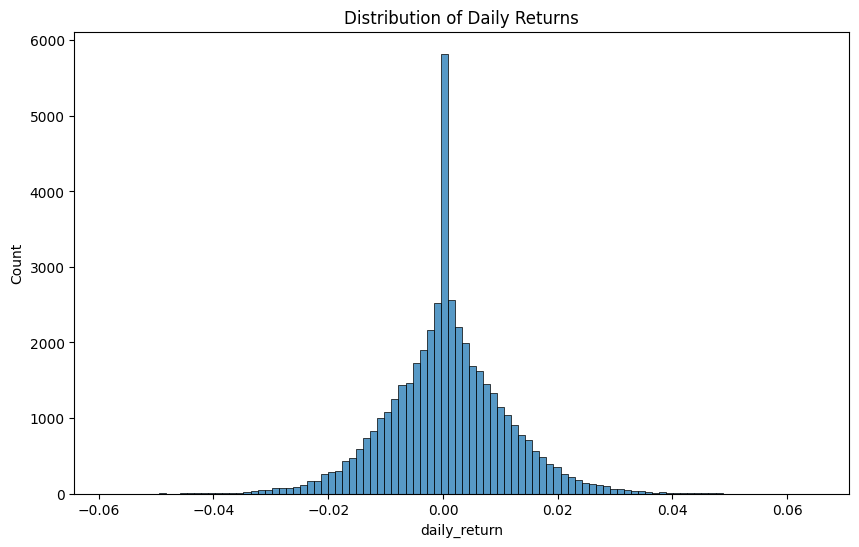

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Distribution of Daily Returns"
)

plt.show()

Insight : Daily returns follow an approximately normal distribution centered around zero, with occasional extreme movements during volatile periods.

Task - 2: 

In [8]:
def calculate_cagr(
    start_nav,
    end_nav,
    years
):

    return (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

In [9]:
cagr_results = []

for code in nav["amfi_code"].unique():

    temp = (
        nav[
            nav["amfi_code"]==code
        ]
        .sort_values("date")
    )

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    cagr_5yr = calculate_cagr(
        start_nav,
        end_nav,
        5
    )

    cagr_results.append(
        [code,cagr_5yr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_5yr"
    ]
)

In [10]:
RF = 0.065

In [11]:
def sharpe_ratio(
    returns
):

    annual_return = (
        returns.mean()
        *252
    )

    annual_std = (
        returns.std()
        *np.sqrt(252)
    )

    return (
        annual_return - RF
    ) / annual_std

In [12]:
sharpe_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"]==code
    ]

    sr = sharpe_ratio(
        temp["daily_return"].dropna()
    )

    sharpe_results.append(
        [code,sr]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio_calc"
    ]
)

In [13]:
sharpe_df = (
    sharpe_df
    .sort_values(
        "sharpe_ratio_calc",
        ascending=False
    )
)

In [14]:
def sortino_ratio(
    returns
):

    downside = (
        returns[
            returns < 0
        ]
    )

    downside_std = (
        downside.std()
        *np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        *252
    )

    return (
        annual_return - RF
    ) / downside_std

In [15]:
sortino_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"]==code
    ]

    ratio = sortino_ratio(
        temp["daily_return"].dropna()
    )

    sortino_results.append(
        [code,ratio]
    )

In [16]:
bench = bench.sort_values(
    ["index_name","date"]
)

bench["benchmark_return"] = (
    bench.groupby("index_name")
         ["close_value"]
         .pct_change()
)

In [17]:
nifty100 = bench[
    bench["index_name"]
    == "NIFTY100"
]

In [18]:
alpha_beta = []

In [19]:
for code in nav["amfi_code"].unique():

    fund = (
        nav[
            nav["amfi_code"]==code
        ][
            ["date","daily_return"]
        ]
    )

    merged = pd.merge(
        fund,
        nifty100[
            [
                "date",
                "benchmark_return"
            ]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, se = (
        linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )
    )

    beta = slope

    alpha = (
        intercept
        *252
    )

    alpha_beta.append(
        [
            code,
            alpha,
            beta
        ]
    )

In [20]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [21]:
dd_results = []

In [22]:
for code in nav["amfi_code"].unique():

    temp = (
        nav[
            nav["amfi_code"]==code
        ]
        .copy()
    )

    temp["running_max"] = (
        temp["nav"]
        .cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        -1
    )

    max_dd = (
        temp["drawdown"]
        .min()
    )

    dd_results.append(
        [code,max_dd]
    )

In [23]:
dd_df = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [24]:
scorecard = (
    perf
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        dd_df,
        on="amfi_code"
    )
)

In [33]:
# print(scorecard.columns)
print(scorecard["alpha_x"][:5], scorecard["alpha_y"][:5])

0    0.87
1    1.78
2    1.23
3    1.13
4    1.60
Name: alpha_x, dtype: float64 0    0.232010
1    0.198686
2    0.303370
3    0.048824
4    0.056209
Name: alpha_y, dtype: float64


In [34]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(
        ascending=False
    )
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio_calc"]
    .rank(
        ascending=False
    )
)

scorecard["alpha_rank_y"] = (
    scorecard["alpha_y"]
    .rank(
        ascending=False
    )
)

scorecard["alpha_rank_x"] = (
    scorecard["alpha_x"]
    .rank(
        ascending=False
    )
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=False
    )
)

In [ ]:
max_rank = len(scorecard)

for col in [
    "return_rank",
    "sharpe_rank",
    "alpha_rank",
    "expense_rank",
    "dd_rank"
]:
    scorecard[col] = (
        max_rank
        - scorecard[col]
        + 1
    )

In [36]:
scorecard["fund_score"] = (

0.30*scorecard["return_rank"]

+0.25*scorecard["sharpe_rank"]

+0.20*(scorecard["alpha_rank_x"] + scorecard["alpha_rank_y"])

+0.15*scorecard["expense_rank"]

+0.10*scorecard["dd_rank"]

)

In [37]:
scorecard["fund_score"] = (

100 *

(
scorecard["fund_score"]

-
scorecard["fund_score"].min()
)

/

(
scorecard["fund_score"].max()

-
scorecard["fund_score"].min()
)

)

In [38]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [39]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

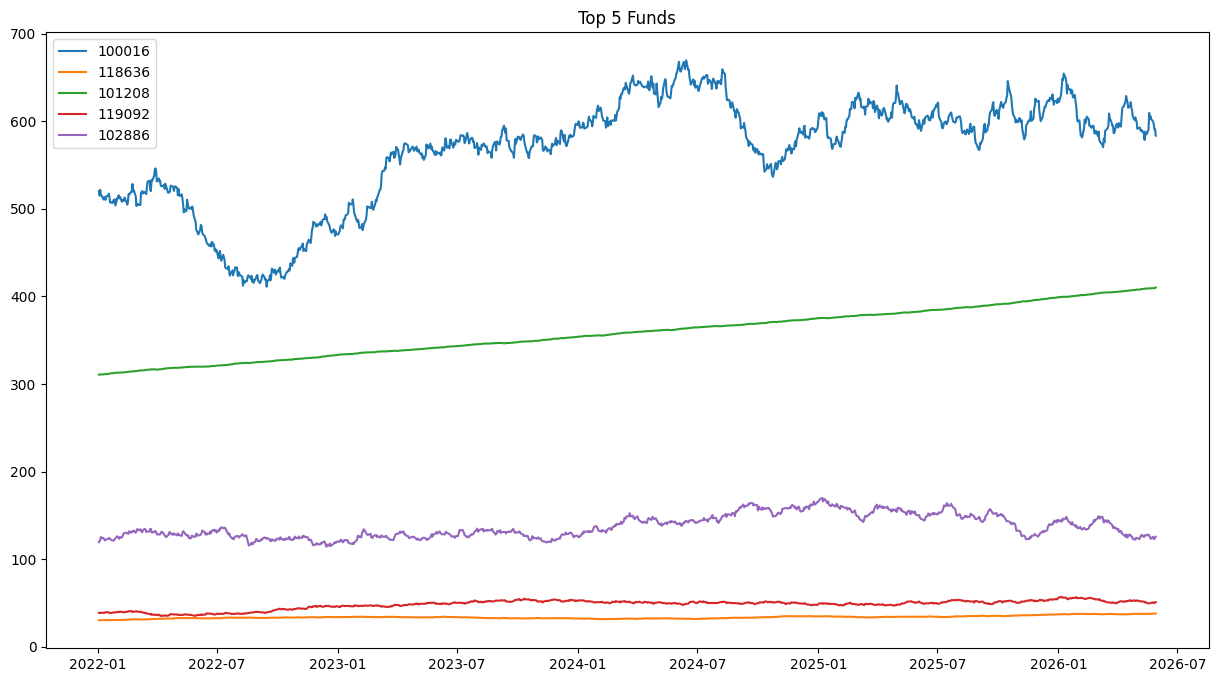

In [40]:
plt.figure(
    figsize=(15,8)
)

for code in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"]==code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds"
)

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()